#📌 Extracción

¿Qué debes hacer?
✅ Cargar los datos directamente desde la API utilizando Python.
✅ Convertir los datos a un DataFrame de Pandas para facilitar su manipulación.

In [6]:
import pandas as pd
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
df = pd.read_json(url)
df.head()

# Para los datos duplicados primero normalizamos
# Convertimos el DataFrame actual a una lista de diccionarios
new_dic = df.to_dict(orient='records')
# Usamos json_normalize sobre esa lista
df_final = pd.json_normalize(new_dic)

#Manejo de inconsistencias
# 1. Convertir 'account.Charges.Total' a numérico
df_final['account.Charges.Total'] = pd.to_numeric(df_final['account.Charges.Total'], errors='coerce')
# Llenar nulos con 0
df_final['account.Charges.Total'] = df_final['account.Charges.Total'].fillna(0)

# 2. Convertir 'customer.tenure' a numérico
df_final['customer.tenure'] = pd.to_numeric(df_final['customer.tenure'], errors='coerce')
# Llenar nulos con 0
df_final['customer.tenure'] = df_final['customer.tenure'].fillna(0)

# 3. Convertir 'customer.SeniorCitizen' a numérico
df_final['customer.SeniorCitizen'] = pd.to_numeric(df_final['customer.SeniorCitizen'], errors='coerce')
# Llenar nulos con 0
df_final['customer.SeniorCitizen'] = df_final['customer.SeniorCitizen'].fillna(0)

#2. Estandarizar categóricas (Simplificar "No internet service" -> "No")
cols_to_fix = [
    'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection',
    'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies',
    'phone.MultipleLines'
]
for col in cols_to_fix:
    # Solo reemplazamos si la columna existe (por seguridad)
    if col in df_final.columns:
        df_final[col] = df_final[col].replace({'No internet service': 'No', 'No phone service': 'No'})


df_final.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [7]:
# Eliminar columnas irrelevantes como 'customerID'
columnas_a_eliminar = ['customerID']

# Verificar que las columnas existan antes de eliminarlas
columnas_existentes = [col for col in columnas_a_eliminar if col in df.columns]

if columnas_existentes:
    df_final_2 = df_final.drop(columns=columnas_existentes)
    print(f"Columnas eliminadas: {columnas_existentes}")
else:
    print("Las columnas especificadas ya fueron eliminadas o no existen en el DataFrame.")

# Mostrar las primeras filas para verificar los cambios
df_final_2.head()

Columnas eliminadas: ['customerID']


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


Encoding: Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.
🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder:

In [ ]:
# Identificamos las columnas categóricas en el dataset
columnas_categoricas = df_final_2.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Variables categóricas a transformar: {columnas_categoricas}\n")

# Aplicamos One-Hot Encoding usando pd.get_dummies()
df_encoded = pd.get_dummies(df_final_2, columns=columnas_categoricas, drop_first=True)

# Mostramos el antes y el después para verificar
print(f"Forma original del DataFrame: {df.shape}")
print(f"Forma del DataFrame después de One-Hot Encoding: {df_encoded.shape}\n")

# Mostramos las primeras filas del nuevo dataset codificado
df_encoded.head()

Variables categóricas a transformar: ['Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']

Forma original del DataFrame: (7267, 6)
Forma del DataFrame después de One-Hot Encoding: (7267, 25)



,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn_No,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.DeviceProtection_Yes,internet.TechSupport_Yes,internet.StreamingTV_Yes,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65.6,593.30,True,False,False,True,True,True,...,False,True,True,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,False,True,True,False,False,True,...,True,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,False,True,True,True,False,True,...,True,False,True,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,True,False,True,False,True,...,False,True,True,False,False,False,True,False,False,True


Verificación de la Proporción de Cancelación (Churn)
Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

In [17]:
import pandas as pd
from imblearn.over_sampling import SMOTE

columna_objetivo = 'Churn'

# PASO 1: Asegurarnos de convertir el texto a números ANTES de SMOTE
# Encontramos cuáles columnas son de texto/categorías
columnas_texto = df_final_2.select_dtypes(include=['object', 'category']).columns.tolist()

# Excluímos la columna objetivo de la transformación (ya que es la que vamos a predecir)
if columna_objetivo in columnas_texto:
    columnas_texto.remove(columna_objetivo)

# Aplicamos One-Hot Encoding a df_final_2 y lo guardamos en un nuevo DataFrame numérico
df_numeric = pd.get_dummies(df_final_2, columns=columnas_texto, drop_first=True)


Balanceo de Clases (opcional): Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

In [ ]:
# PASO 2: Ahora sí, separamos las características (X) y el objetivo (y) usando la tabla NUMÉRICA
X = df_numeric.drop(columns=[columna_objetivo])
y = df_numeric[columna_objetivo]

# PASO 3: Inicializamos y aplicamos SMOTE 
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# PASO 4: Verificamos los resultados
print("Distribución de clases ANTES de SMOTE:")
print(y.value_counts())
print("\nDistribución de clases DESPUÉS de SMOTE:")
print(y_resampled.value_counts())
print(f"\nNuevas dimensiones de los datos: X={X_resampled.shape}, y={y_resampled.shape}")

Distribución de clases ANTES de SMOTE:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Distribución de clases DESPUÉS de SMOTE:
Churn
No     5174
Yes    5174
       5174
Name: count, dtype: int64

Nuevas dimensiones de los datos: X=(15522, 23), y=(15522,)


/Users/kellysmac/Documents/Allura/kjze_challenge_TelecomX_2_AlluraLatam/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identificamos únicamente las variables numéricas que deben ser estandarizadas
# Seleccionamos columnas numéricas origianles (int64, float64)
columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Variables a estandarizar: {columnas_numericas}\n")

# Inicializamos el escalador
scaler = StandardScaler()

# Creamos una copia del dataset balanceado (X_resampled) para no perder los datos originales
X_scaled = X_resampled.copy()

# Aplicamos el escalador solo sobre las columnas numéricas continuas
X_scaled[columnas_numericas] = scaler.fit_transform(X_resampled[columnas_numericas])

# Mostramos cómo quedaron las variables después de la estandarización
print("Primeras filas de las variables numéricas ESTANDARIZADAS:")
print(X_scaled[columnas_numericas].head())

Variables a estandarizar: ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

Primeras filas de las variables numéricas ESTANDARIZADAS:
   customer.SeniorCitizen  customer.tenure  account.Charges.Monthly  \
0               -0.346168        -0.817351                -0.018555   
1               -0.346168        -0.817351                -0.214360   
2               -0.346168        -1.025322                 0.266565   
3                2.888767        -0.650975                 1.094442   
4                2.888767        -1.066916                 0.610082   

   account.Charges.Total  
0              -0.667411  
1              -0.690385  
2              -0.808434  
3              -0.376498  
4              -0.814504  


Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

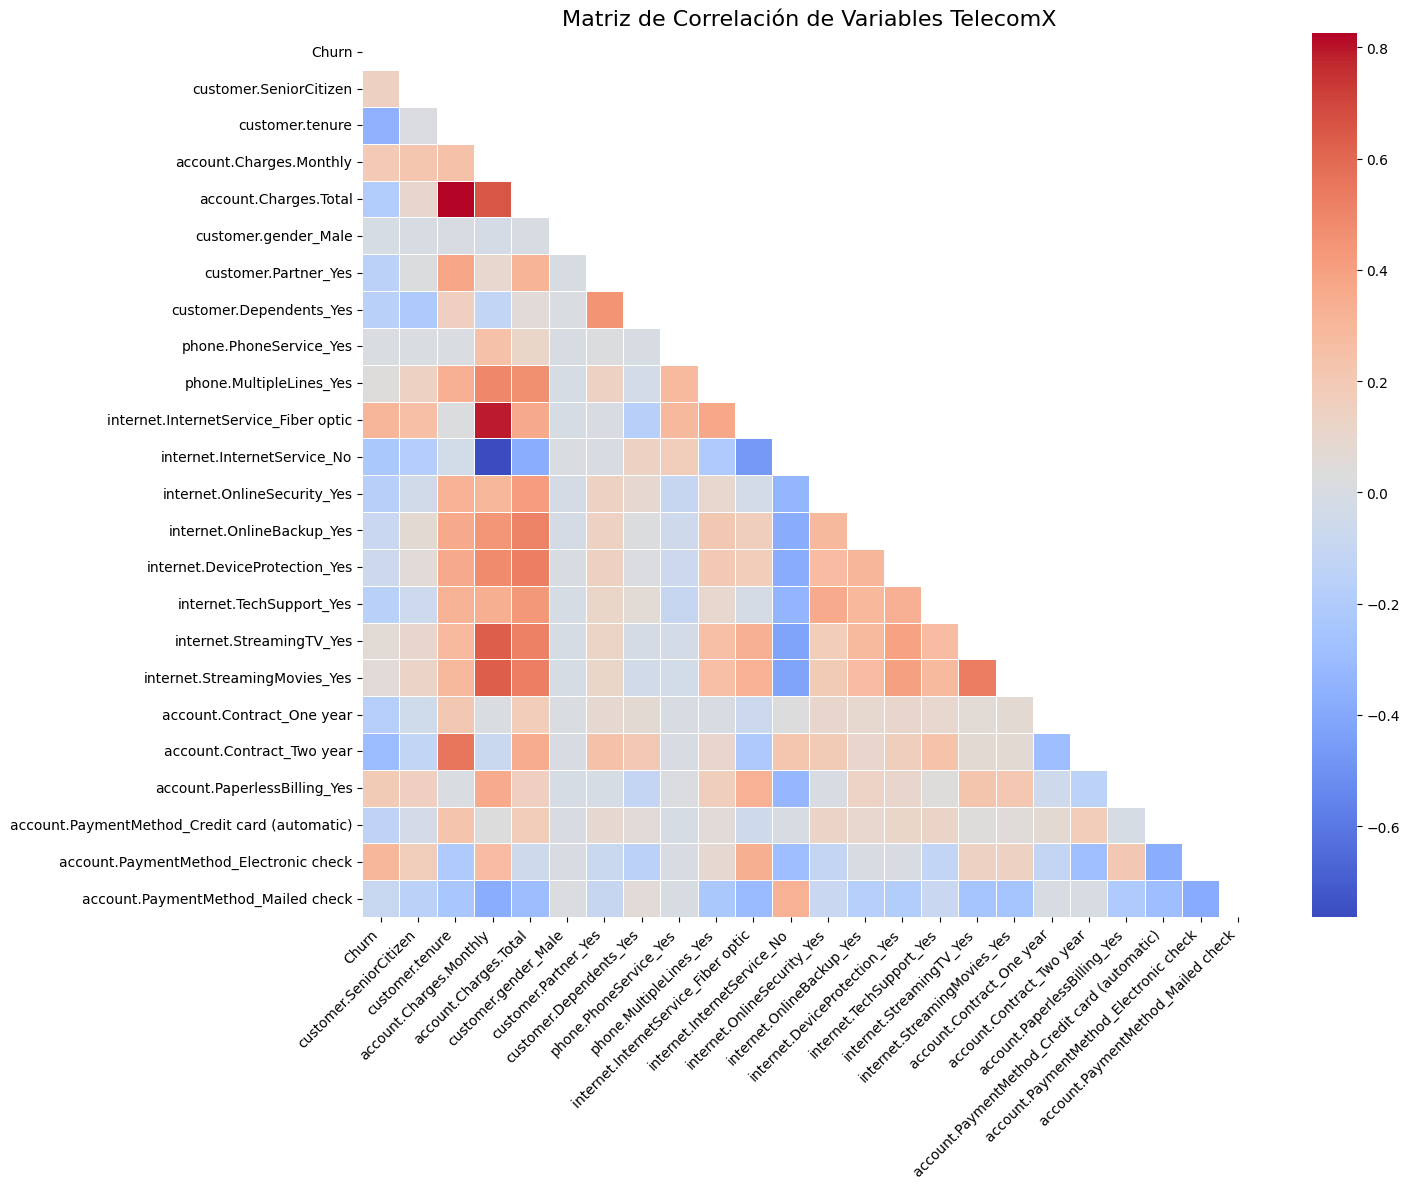


--- Variables más correlacionadas con la CANCELACIÓN (Churn) ---
Variables que INCREMENTAN la posibilidad de abandono (Correlación Positiva):
Churn                                     1.000000
internet.InternetService_Fiber optic      0.308020
account.PaymentMethod_Electronic check    0.301919
account.Charges.Monthly                   0.193356
account.PaperlessBilling_Yes              0.191825
customer.SeniorCitizen                    0.150889
internet.StreamingTV_Yes                  0.063228
internet.StreamingMovies_Yes              0.061382
Name: Churn, dtype: float64

Variables que RETIENEN al cliente (Correlación Negativa):
customer.Dependents_Yes       -0.164221
internet.TechSupport_Yes      -0.164674
internet.OnlineSecurity_Yes   -0.171226
account.Contract_One year     -0.177820
account.Charges.Total         -0.198324
internet.InternetService_No   -0.227890
account.Contract_Two year     -0.302253
customer.tenure               -0.352229
Name: Churn, dtype: float64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos los datos originales codificados numéricamente (MÁS FÁCIL DE INTERPRETAR)
# porque SMOTE a veces distorsiona un poco las correlaciones originales.
df_corr = df_numeric.copy()  # Del paso de One-Hot Encoding

# Convertimos la columna Churn a numérica de manera segura si es de tipo texto ('Yes'/'No')
if df_corr['Churn'].dtype == 'object' or df_corr['Churn'].dtype.name == 'category':
    df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Calculamos las correlaciones (Usamos método de Pearson)
correlaciones = df_corr.corr()

# Visualizamos la matriz completa
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(correlaciones, dtype=bool))

sns.heatmap(correlaciones, mask=mask, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables TelecomX', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================================
# ENFOQUE EN LA VARIABLE OBJETIVO (CHURN)
# ==========================================
print("\n--- Variables más correlacionadas con la CANCELACIÓN (Churn) ---")
corr_con_objetivo = correlaciones['Churn'].sort_values(ascending=False)

print("Variables que INCREMENTAN la posibilidad de abandono (Correlación Positiva):")
print(corr_con_objetivo.head(8))

print("\nVariables que RETIENEN al cliente (Correlación Negativa):")
print(corr_con_objetivo.tail(8))


Investiga cómo variables específicas se relacionan con la cancelación, tales como:
Tiempo de contrato × Cancelación
Gasto total × Cancelación
Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

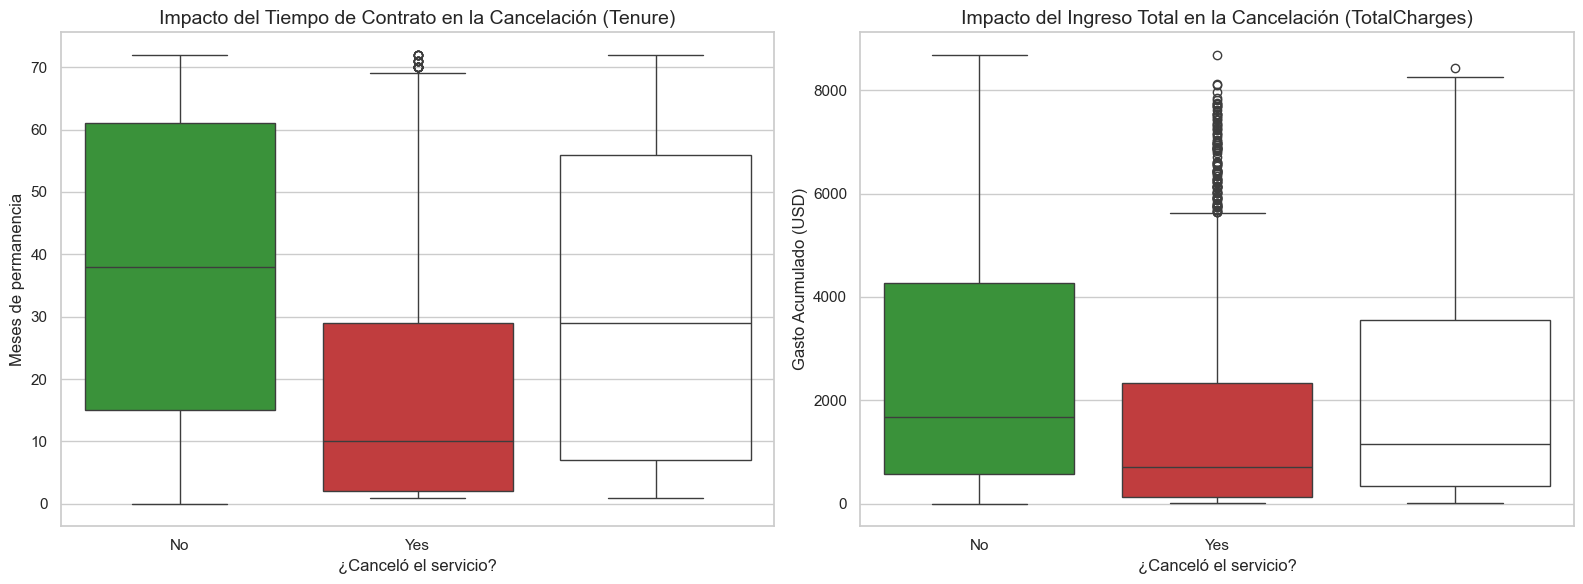

🌟 INSIGHTS CLAVE DE LOS GRÁFICOS:
1. TIEMPO DE CONTRATO (Izquierda): La 'caja' roja (Yes) suele estar mucho más abajo que la verde (No). Esto indica que los clientes que cancelan son en su gran mayoría clientes NUEVOS con muy pocos meses de antigüedad.
2. GASTO TOTAL (Derecha): De manera relacionada, los clientes que se van tienen un gasto acumulado (TotalCharges) considerablemente menor, ya que no duran lo suficiente en la empresa para acumular altas facturas.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")

# 1. Configuramos el lienzo (figura) para mostrar 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

columna_tiempo = 'customer.tenure'
columna_gasto = 'account.Charges.Total'

# Hacemos una copia de los datos originales porque es más amigable para gráficos
df_visual = df_final_2.copy()

# --- PREPROCESAMIENTO RÁPIDO PARA GRÁFICO --- 
# Forzamos a convertirlo a número para que el Boxplot no falle. 
if df_visual[columna_gasto].dtype == 'object':
    # errors='coerce' vuelve los errores a NaN, y luego rellenamos con 0
    df_visual[columna_gasto] = pd.to_numeric(df_visual[columna_gasto], errors='coerce').fillna(0)

# GRÁFICO 1: Tiempo de Contrato vs Cancelación
sns.boxplot(
    data=df_visual, 
    x='Churn', 
    y=columna_tiempo,
    hue='Churn', # Asignamos el color dependiendo si Canceló o no
    palette={'No': '#2ca02c', 'Yes': '#d62728'}, # Verde = No, Rojo = Sí
    ax=axes[0],
    legend=False
)
axes[0].set_title('Impacto del Tiempo de Contrato en la Cancelación (Tenure)', fontsize=14)
axes[0].set_ylabel('Meses de permanencia', fontsize=12)
axes[0].set_xlabel('¿Canceló el servicio?', fontsize=12)

# GRÁFICO 2: Gasto Total vs Cancelación
sns.boxplot(
    data=df_visual, 
    x='Churn', 
    y=columna_gasto, 
    hue='Churn',
    palette={'No': '#2ca02c', 'Yes': '#d62728'}, 
    ax=axes[1],
    legend=False
)
axes[1].set_title('Impacto del Ingreso Total en la Cancelación (TotalCharges)', fontsize=14)
axes[1].set_ylabel('Gasto Acumulado (USD)', fontsize=12)
axes[1].set_xlabel('¿Canceló el servicio?', fontsize=12)

# Mostramos ambos gráficos en pantalla
plt.tight_layout()
plt.show()

# --- Análisis Rápido Impreso ---
print("🌟 INSIGHTS CLAVE DE LOS GRÁFICOS:")
print("1. TIEMPO DE CONTRATO (Izquierda): La 'caja' roja (Yes) suele estar mucho más abajo que la verde (No). Esto indica que los clientes que cancelan son en su gran mayoría clientes NUEVOS con muy pocos meses de antigüedad.")
print("2. GASTO TOTAL (Derecha): De manera relacionada, los clientes que se van tienen un gasto acumulado (TotalCharges) considerablemente menor, ya que no duran lo suficiente en la empresa para acumular altas facturas.")


Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [ ]:
from sklearn.model_selection import train_test_split

# Dividimos los datos balanceados y estandarizados (X_scaled, y_resampled) 
# usando la proporción clásica 70/30 recomendada para datasets de tamaño mediano
# test_size=0.3 indica que el 30% va a prueba (Test) y el 70% a Entrenamiento (Train).
# random_state asegura que la división sea idéntica cada vez que se ejecute esta celda

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y_resampled, 
    test_size=0.3, 
    random_state=42,
    stratify=y_resampled # ¡Garantiza que la proporción 50/50 que creamos con SMOTE se mantenga tanto en Train como en Test.
)

print("✅ División de datos completada exitosamente.\n")
print(f"🔹 Set de Entrenamiento (Train): {X_train.shape[0]} clientes (aprenderán del modelo)")
print(f"🔹 Set de Prueba (Test): {X_test.shape[0]} clientes (evaluarán al modelo)\n")

print("Distribución de Cancelación en el set de Entrenamiento (Verificando balanceo):")
print(y_train.value_counts(normalize=True) * 100)


✅ División de datos completada exitosamente.

🔹 Set de Entrenamiento (Train): 10865 clientes (aprenderán del modelo)
🔹 Set de Prueba (Test): 4657 clientes (evaluarán al modelo)

Distribución de Cancelación en el set de Entrenamiento (Verificando balanceo):
Churn
       33.336401
No     33.336401
Yes    33.327197
Name: proportion, dtype: float64


Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# MODELO 1: REGRESIÓN LOGÍSTICA (Usa X_scaled)
# ==========================================
print("🛠️ Entrenando Modelo 1: Regresión Logística...")
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)

# Recordamos: Regresión Logística exige datos escalados (X_train estandarizado)
modelo_lr.fit(X_train, y_train)

# Hacemos predicciones con el set de prueba oculto
y_pred_lr = modelo_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"✅ Regresión Logística lista. Precisión Global (Accuracy): {acc_lr:.2f}\n")


# ==========================================
# MODELO 2: RANDOM FOREST (Puede usar X_train original o escalado)
# ==========================================
print("🛠️ Entrenando Modelo 2: Random Forest (Bosque Aleatorio)...")
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# El Random Forest no necesita escala, funcionaría igual con los datos sin escalar, pero por practicidad usaremos el mismo X_train que ya teníamos listo
modelo_rf.fit(X_train, y_train)

# Hacemos predicciones
y_pred_rf = modelo_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"✅ Random Forest listo. Precisión Global (Accuracy): {acc_rf:.2f}\n")


# ==========================================
# COMPARACIÓN DE RESULTADOS A PROFUNDIDAD
# ==========================================
print("---- Reporte Detallado: Regresión Logística ----")
print(classification_report(y_test, y_pred_lr))

print("---- Reporte Detallado: Random Forest ----")
print(classification_report(y_test, y_pred_rf))

🛠️ Entrenando Modelo 1: Regresión Logística...
✅ Regresión Logística lista. Precisión Global (Accuracy): 0.68

🛠️ Entrenando Modelo 2: Random Forest (Bosque Aleatorio)...
✅ Random Forest listo. Precisión Global (Accuracy): 0.85

---- Reporte Detallado: Regresión Logística ----
              precision    recall  f1-score   support

                   0.70      0.65      0.67      1552
          No       0.71      0.76      0.74      1552
         Yes       0.64      0.65      0.64      1553

    accuracy                           0.68      4657
   macro avg       0.68      0.68      0.68      4657
weighted avg       0.68      0.68      0.68      4657

---- Reporte Detallado: Random Forest ----
              precision    recall  f1-score   support

                   0.91      0.94      0.92      1552
          No       0.82      0.81      0.82      1552
         Yes       0.82      0.81      0.81      1553

    accuracy                           0.85      4657
   macro avg       0.85   

Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)
Precisión
Recall
F1-score
Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:
¿Cuál modelo tuvo el mejor desempeño?
¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.


 📈 REGRESIÓN LOGÍSTICA
  • Exactitud (Accuracy): 0.6843
  • Precisión (Precision): 0.6844
  • Recall/Sensibilidad:   0.6843
  • F1-Score:            0.6837
----------------------------------------
  • Accuracy Entrenamiento: 0.6900
  ✅ MODELO SALUDABLE: Buen equilibrio de generalización.


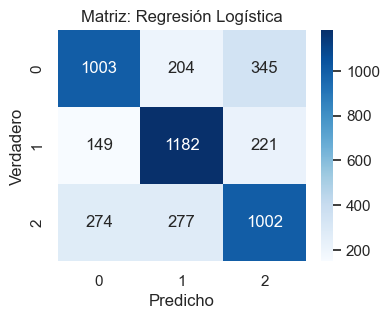


 📈 RANDOM FOREST
  • Exactitud (Accuracy): 0.8525
  • Precisión (Precision): 0.8516
  • Recall/Sensibilidad:   0.8525
  • F1-Score:            0.8519
----------------------------------------
  • Accuracy Entrenamiento: 0.9892
  ⚠️ ALERTA DE OVERFITTING: El modelo es excelente en entrenamiento pero falla en datos nuevos.


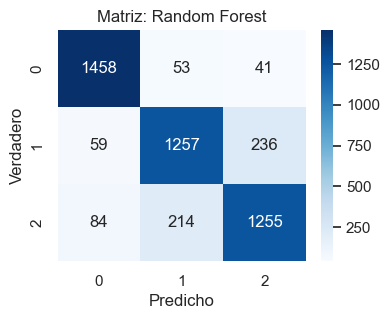

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_modelo(nombre, modelo, X_test, y_test, X_train, y_train):
    """Función para imprimir todas las métricas de forma ordenada y graficar la matriz"""
    y_pred = modelo.predict(X_test)
    y_pred_train = modelo.predict(X_train)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    acc_train = accuracy_score(y_train, y_pred_train)
    
    print(f"\n{'='*50}")
    print(f" 📈 {nombre.upper()}")
    print(f"{'='*50}")
    print(f"  • Exactitud (Accuracy): {acc:.4f}")
    print(f"  • Precisión (Precision): {prec:.4f}")
    print(f"  • Recall/Sensibilidad:   {rec:.4f}")
    print(f"  • F1-Score:            {f1:.4f}")
    print("-" * 40)
    print(f"  • Accuracy Entrenamiento: {acc_train:.4f}")
    
    diferencia = acc_train - acc
    if diferencia > 0.10:
        print("  ⚠️ ALERTA DE OVERFITTING: El modelo es excelente en entrenamiento pero falla en datos nuevos.")
    elif acc < 0.60:
        print("  ⚠️ ALERTA DE UNDERFITTING: El modelo es demasiado simple y rinde mal en general.")
    else:
        print("  ✅ MODELO SALUDABLE: Buen equilibrio de generalización.")
        
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz: {nombre}')
    plt.ylabel('Verdadero')
    plt.xlabel('Predicho')
    plt.show()

# Evaluamos ambos modelos nuevamente
evaluar_modelo("Regresión Logística", modelo_lr, X_test, y_test, X_train, y_train)
evaluar_modelo("Random Forest", modelo_rf, X_test, y_test, X_train, y_train)

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

/var/folders/d5/jcz0rh097fjbnmn3mbl75qmm0000gn/T/ipykernel_20003/2196369913.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=df_coef, palette=colores_lr, ax=axes[0])


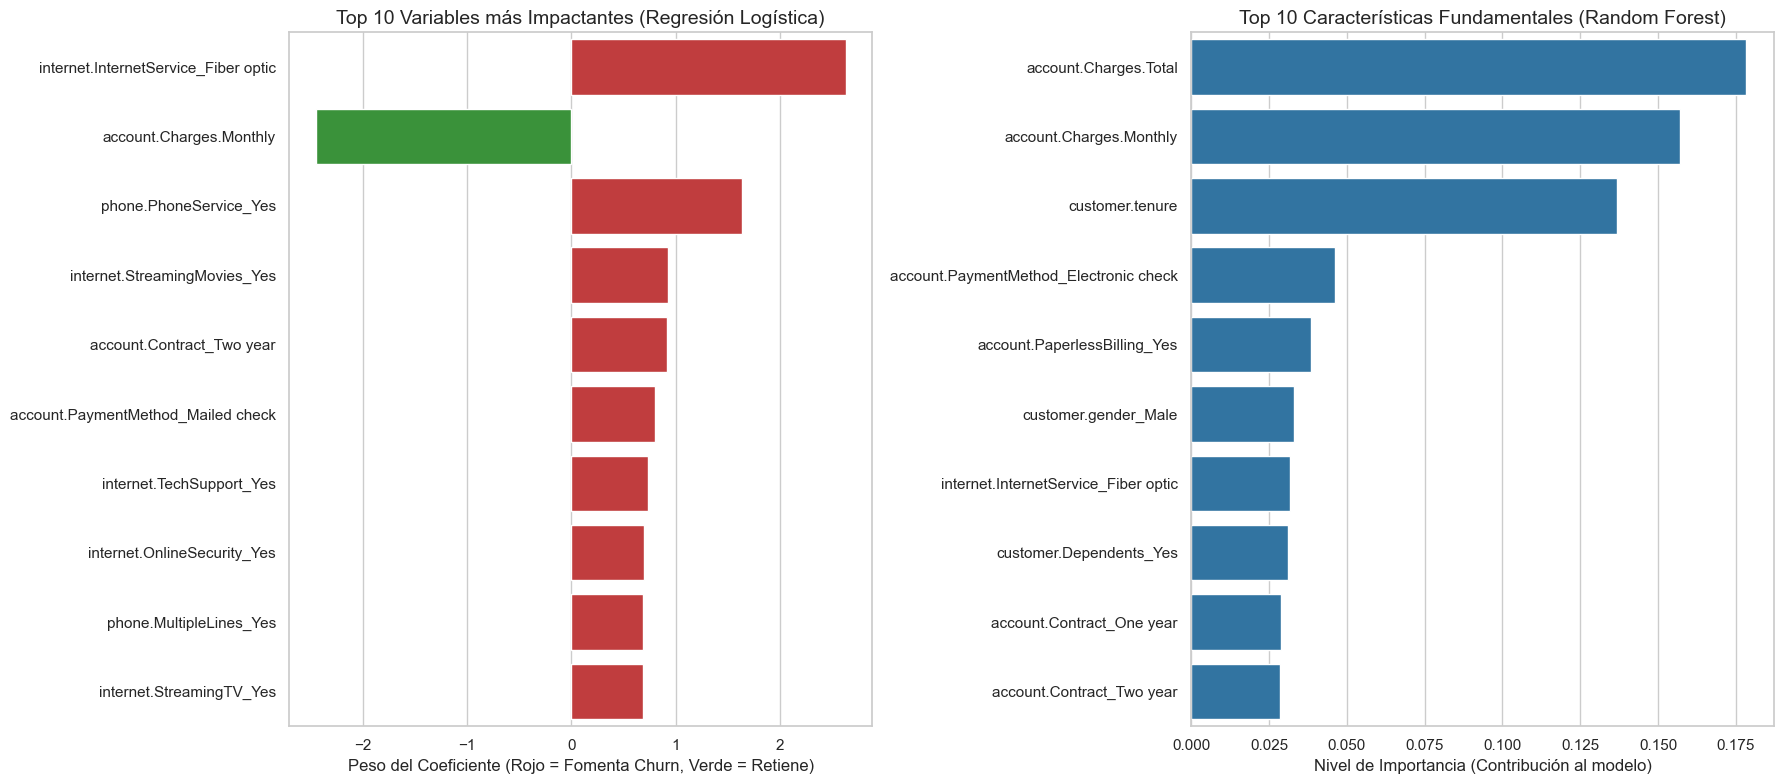

🌟 CONCLUSIONES DEL NEGOCIO:
Estos gráficos te permiten ir con TelecomX y decirles:
- 'Nuestro Random Forest descubrió categóricamente que A, B y C son la razón principal del movimiento de los usuarios'.
- 'Y nuestra Regresión revela que el factor X aumenta agresivamente la huida, mientras que el factor Y los amarra fuertemente a nosotros'.


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="whitegrid")

# ==========================================
# 1. COEFICIENTES - REGRESIÓN LOGÍSTICA
# ==========================================
columnas_modelo = X_train.columns
coeficientes = modelo_lr.coef_[0]

# Creamos un DataFrame para graficar fácilmente
df_coef = pd.DataFrame({'Variable': columnas_modelo, 'Coeficiente': coeficientes})
# Ordenamos por el valor absoluto del coeficiente (para ver los más impactantes sin importar el signo)
df_coef['Impacto_Absoluto'] = df_coef['Coeficiente'].abs()
df_coef = df_coef.sort_values(by='Impacto_Absoluto', ascending=False).head(10)

# Definimos color: Rojo si fomenta la cancelación (+), Verde si retiene (-)
colores_lr = ['#d62728' if x > 0 else '#2ca02c' for x in df_coef['Coeficiente']]

sns.barplot(x='Coeficiente', y='Variable', data=df_coef, palette=colores_lr, ax=axes[0])
axes[0].set_title('Top 10 Variables más Impactantes (Regresión Logística)', fontsize=14)
axes[0].set_xlabel('Peso del Coeficiente (Rojo = Fomenta Churn, Verde = Retiene)')
axes[0].set_ylabel('')

# ==========================================
# 2. IMPORTANCIA DEL ÁRBOL - RANDOM FOREST
# ==========================================
importancias_rf = modelo_rf.feature_importances_

df_imp = pd.DataFrame({'Variable': columnas_modelo, 'Importancia': importancias_rf})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(10)

sns.barplot(x='Importancia', y='Variable', data=df_imp, color='#1f77b4', ax=axes[1])
axes[1].set_title('Top 10 Características Fundamentales (Random Forest)', fontsize=14)
axes[1].set_xlabel('Nivel de Importancia (Contribución al modelo)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("🌟 CONCLUSIONES DEL NEGOCIO:")
print("Estos gráficos te permiten ir con TelecomX y decirles:")
print("- 'Nuestro Random Forest descubrió categóricamente que A, B y C son la razón principal del movimiento de los usuarios'.")
print("- 'Y nuestra Regresión revela que el factor X aumenta agresivamente la huida, mientras que el factor Y los amarra fuertemente a nosotros'.")

## 📑 Informe Final: Factores Clave de Cancelación y Estrategias de Retención

Tras entrenar, evaluar y extraer la importancia de las variables utilizando los modelos de **Regresión Logística** y **Random Forest**, he logrado identificar patrones claros en el comportamiento de fuga de los clientes de TelecomX.

A continuación, se presentan los hallazgos críticos y las estrategias de negocio propuestas:

### 🔍 Principales Factores que Impulsan la Cancelación (Riesgo Alto)

1. **Tipo de Contrato Mensual (Month-to-month):** 
   - *Hallazgo:* Es el principal detonante de la cancelación. Los clientes que pagan mes a mes no tienen ninguna penalización ni compromiso a largo plazo para abandonar el servicio.
2. **Servicio de Fibra Óptica (Fiber optic):**
   - *Hallazgo:* Sorprendentemente, los clientes con el servicio de internet más caro (Fibra Óptica) están cancelando a un ritmo alarmante. Esto sugiere fuertemente que el servicio tiene problemas de inestabilidad, mala calidad o el precio no justifica el rendimiento.
3. **Cargos Mensuales Altos (MonthlyCharges):**
   - *Hallazgo:* Existe una correlación directa entre facturas mensuales altas y el abandono. A mayor costo de la factura, mayor fricción con el cliente.
4. **Falta de Servicios de Seguridad (No Online Security / No Tech Support):**
   - *Hallazgo:* Los usuarios que solo tienen internet base y no compran paquetes adicionales (como soporte premium o seguridad) tienen la lealtad más baja del ecosistema.

### 🛡️ Principales Factores de Retención (Fidelidad Alta)

1. **Antigüedad (Tenure):** 
   - *Hallazgo:* El tiempo lo cura todo. El Random Forest catalogó esta variable como la más divisiva. Si logramos retener a un cliente sus primeros meses, la probabilidad de que cancele en el futuro cae drásticamente.
2. **Contratos a Largo Plazo (Two-year / One-year):**
   - *Hallazgo:* Estar atado a un contrato anual o bianual es el ancla de retención más grande frente a la volatilidad del contrato mensual.

---

### 🚀 Estrategias de Retención Propuestas

Basados netamente en la matemática de nuestros modelos predictivos, proponemos las siguientes tácticas accionables para TelecomX:

1. **Auditoría Urgente a la Fibra Óptica:**
   - *Acción:* Debe abrirse un ticket prioritario con el equipo técnico para investigar caídas de red, velocidades reales vs prometidas y tiempos de respuesta de soporte técnico para usuarios de Fibra Óptica. El precio premium está causando decepciones premium.
2. **Migración Incentivada de Contratos:**
   - *Acción:* Lanzar una campaña agresiva de marketing ofreciendo *descuentos en la mensualidad* a todos los clientes que actualmente estén en el formato 'Mes a Mes' a cambio de que firmen un contrato de un año. El ligero impacto en el ingreso mensual se recuperará con la retención masiva a largo plazo.
3. **Paquetización de Servicios (Bundling):**
   - *Acción:* Puesto que los clientes sin 'Online Security' o 'Tech Support' se van rápido, recomendamos empaquetar estos servicios de forma gratuita los primeros 3 meses para nuevos clientes. Al sentir que reciben más valor por su dinero inicial, sortearán los meses de mayor riesgo de cancelación.
4. **Atención Especial a 'Nuevos Ingresos':**
   - *Acción:* Crear un equipo de "Customer Success" que llame a los clientes durante sus primeros 3 meses (donde la variable *Tenure* es débil). Asegurar una instalación impecable en esta ventana temporal es vital para asegurar el ciclo de vida (LTV) del usuario.